In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
with open("E:\\Rohanta_AI_workbook\\campus_chatbot\\data\\campus_kb.json", encoding="utf-8") as f:
    kb = json.load(f)

df_kb = pd.DataFrame(kb)

In [3]:
df_kb.head()

,id,name,category,description,opening_hours,coordinates,map_reference,directions_from_entrance,directions_by_floor,nearby_landmarks,...,classrooms,labs,teachers_room,hod_room,department,room_number,capacity,lab_name,equipment,hod_title
0,1,Main Library,library,A four-floor academic library with over 500 st...,"{'monday': '08:00-22:00', 'tuesday': '08:00-22...","{'lat': 52.5074, 'lng': 13.4021}","Building A, North Campus, Ground to 4th Floor",Enter through the Main Gate. Walk straight 100...,"{'ground_floor': 'Reception, issue desk, newsp...","Opposite the Student Union, next to Admissions...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Main Cafeteria,cafeteria,The primary dining facility on campus offering...,"{'monday': '07:30-20:00', 'tuesday': '07:30-20...","{'lat': 52.5069, 'lng': 13.4018}","Building B, South Campus, Ground Floor",Enter through the Main Gate. Take the left for...,NaN,"Next to Coffee Shop and Printing Centre, south...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Lecture Hall A,lecture_hall,A large auditorium-style lecture hall seating ...,"{'monday': '08:00-21:00', 'tuesday': '08:00-21...","{'lat': 52.5077, 'lng': 13.4025}","Building C, East Wing, Ground Floor",Enter through the Main Gate. Walk 80 metres. T...,NaN,"East of Main Library, next to Lecture Hall B",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Student Union,student_union,The hub of student life. Houses student societ...,"{'monday': '09:00-22:00', 'tuesday': '09:00-22...","{'lat': 52.5071, 'lng': 13.403}","Building D, Central Campus, 1st Floor",Enter through the Main Gate. Walk 100 metres t...,NaN,"Central Campus, opposite the fountain",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,IT & Computer Lab,it_lab,A computer lab with 120 workstations running W...,"{'monday': '08:00-22:00', 'tuesday': '08:00-22...","{'lat': 52.508, 'lng': 13.4022}","Building E, North Wing, 2nd Floor, Room E-201",Enter through the Main Gate. Walk 120 metres p...,NaN,"North of Main Library, behind Building A",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
summary = df_kb[['id','name','category']].copy()
print(summary.to_string(index=False))

 id                                              name            category
  1                                      Main Library             library
  2                                    Main Cafeteria           cafeteria
  3                                    Lecture Hall A        lecture_hall
  4                                     Student Union       student_union
  5                                 IT & Computer Lab              it_lab
  6                           Sports & Fitness Centre                 gym
  7                      Admissions & Registry Office        admin_office
  8                            Career Services Centre       career_center
  9                      Medical & Counselling Centre      medical_center
 10                                Seminar Room Block        seminar_room
 11                                   Main Auditorium          auditorium
 12                      Printing & Stationery Centre       printing_room
 13                     International 

C:\Users\dell\AppData\Local\Temp\ipykernel_2188\3309864380.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(category_counts.index, rotation=40, ha='right')


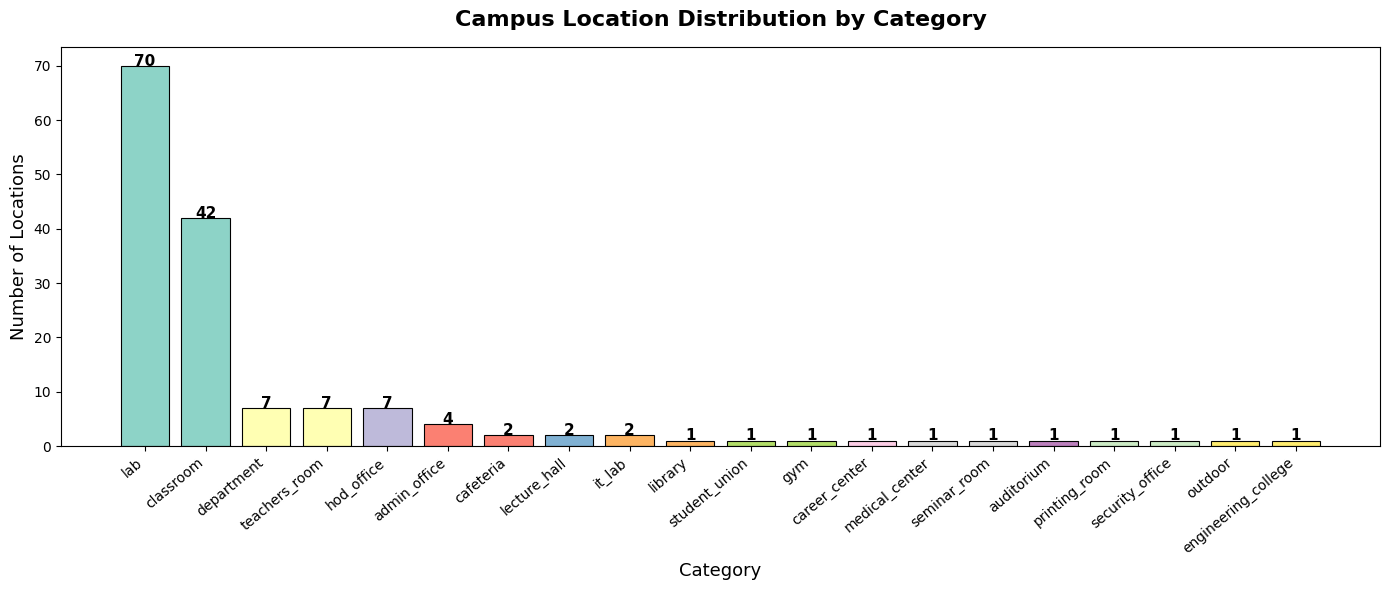

✅ Plot saved: data/category_distribution.png


In [5]:
category_counts = df_kb['category'].value_counts()

colors = plt.cm.Set3(np.linspace(0, 1, len(category_counts)))

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(category_counts.index, category_counts.values,
              color=colors, edgecolor='black', linewidth=0.8)

ax.set_title('Campus Location Distribution by Category', 
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Category', fontsize=13)
ax.set_ylabel('Number of Locations', fontsize=13)
ax.set_xticklabels(category_counts.index, rotation=40, ha='right')

for bar, val in zip(bars, category_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            str(val), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: data/category_distribution.png")

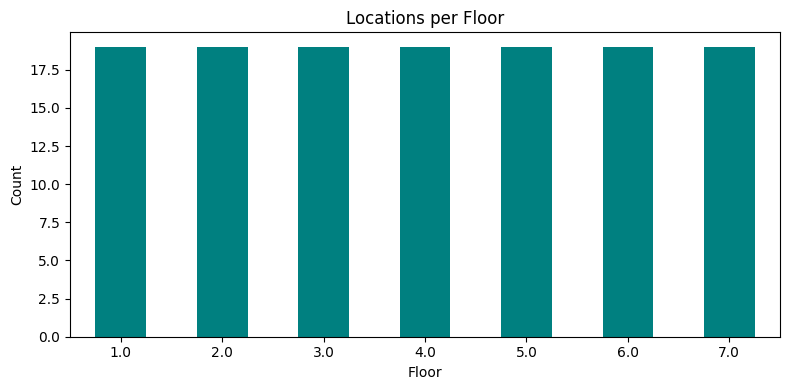

✅ Plot saved: data/floor_counts.png


In [9]:
floor_counts = df_kb['floor'].value_counts().sort_index()
floor_counts.plot(kind='bar', figsize=(8, 4), title='Locations per Floor', color='teal')
plt.xlabel('Floor')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/floor_counts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: data/floor_counts.png")

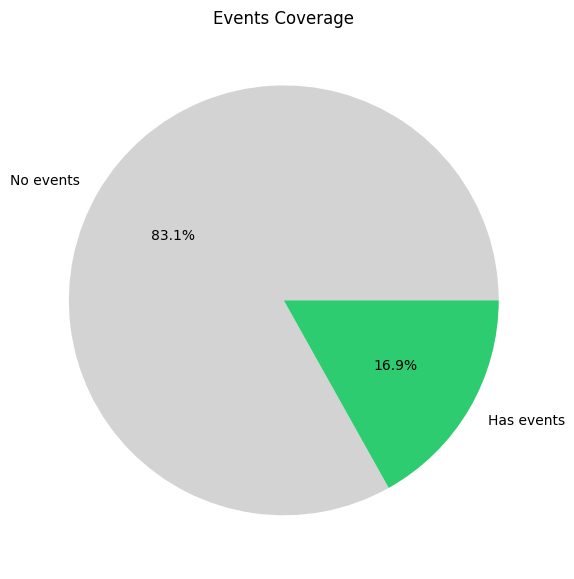

✅ Plot saved: data/event_counts.png


In [11]:
df_kb['has_events'] = df_kb['events'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)
event_counts = df_kb['has_events'].value_counts()
event_counts.index = ['No events', 'Has events']
event_counts.plot(kind='pie', figsize=(6, 6), title='Events Coverage', autopct='%1.1f%%', colors=['#d3d3d3', '#2ecc71'])
plt.ylabel('')
plt.tight_layout()
plt.savefig('../data/event_counts', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: data/event_counts.png")

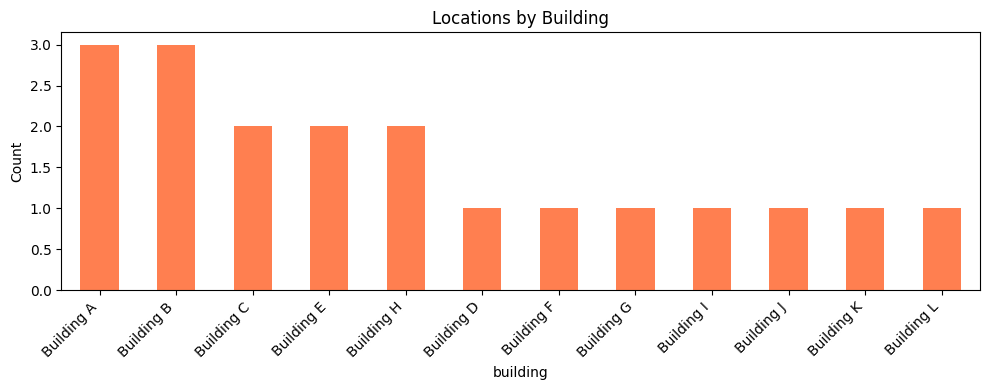

✅ Plot saved: data/building_counts.png


<Figure size 640x480 with 0 Axes>

In [18]:
df_kb['building'] = df_kb['map_reference'].str.extract(r'(Building [A-Z])')
building_counts = df_kb['building'].value_counts()
building_counts.plot(kind='bar', figsize=(10, 4), title='Locations by Building', color='coral')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.savefig('../data/building_counts', dpi=150, bbox_inches='tight')
print("✅ Plot saved: data/building_counts.png")

In [14]:
departments = df_kb[df_kb['category'] == 'department']['name'].tolist()
print(f"Total departments: {len(departments)}")
for i, dept in enumerate(departments, 1):
    print(f"  {i}. {dept}")

Total departments: 7
  1. Mechanical Engineering Department
  2. Chemical Engineering Department
  3. Information Technology Department
  4. Computer Engineering Department
  5. Electronics & Telecommunication (ENTC) Department
  6. Electrical Engineering Department
  7. Civil Engineering Department
